# Notebook 04: Exploratory Data Analysis & Visualization

## I. Giới thiệu
Mục tiêu: Khám phá, trực quan hóa và hiểu sâu hơn về bộ dữ liệu, tìm ra các xu hướng, tính mùa vụ của nhiệt độ toàn cầu (cụ thể tại Tokyo).


## II. Đọc dữ liệu sạch


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Đang nạp dữ liệu 5 thành phố...")

# Tuyệt chiêu: Ép Pandas lấy thẳng cột đầu tiên làm Index và tự động nhận diện thời gian
city_df = pd.read_csv('../data/processed/top5_cities_cleaned.csv', index_col=0, parse_dates=True)

# Đặt lại tên cho index là 'dt' để các ô vẽ biểu đồ bên dưới (dùng city_df.index.month) không bị ngợp
city_df.index.name = 'dt'

print(f"Kích thước dữ liệu: {city_df.shape}")
print(city_df.head())

Đang nạp dữ liệu 5 thành phố...
Kích thước dữ liệu: (9823, 6)
            AverageTemperature  AverageTemperatureUncertainty   City Country  \
dt                                                                             
1850-01-01              -0.066                          1.620  Tokyo   Japan   
1850-02-01               1.769                          2.006  Tokyo   Japan   
1850-03-01               5.414                          2.540  Tokyo   Japan   
1850-04-01               9.283                          1.990  Tokyo   Japan   
1850-05-01              14.455                          1.660  Tokyo   Japan   

           Latitude Longitude  
dt                             
1850-01-01   36.17N   139.23E  
1850-02-01   36.17N   139.23E  
1850-03-01   36.17N   139.23E  
1850-04-01   36.17N   139.23E  
1850-05-01   36.17N   139.23E  


## III. Khám phá dữ liệu
### 1. Phân tích biến mục tiêu (Target Analysis)
Phân bố của AverageTemperature.


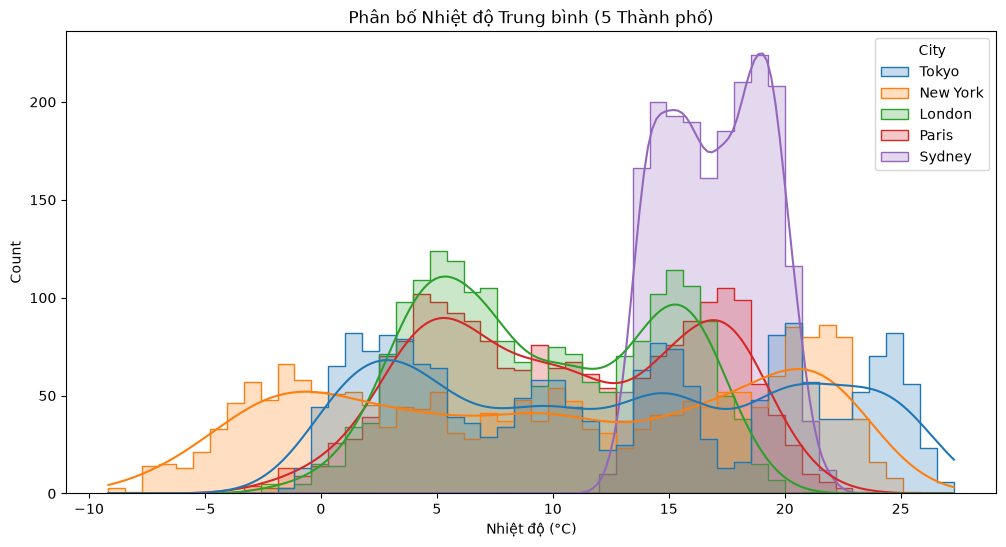

In [20]:
plt.figure(figsize=(12, 6))
# Dùng hue='City' để vẽ 5 màu cho 5 thành phố
sns.histplot(data=city_df, x='AverageTemperature', hue='City', bins=50, kde=True, element="step")
plt.title('Phân bố Nhiệt độ Trung bình (5 Thành phố)')
plt.xlabel('Nhiệt độ (°C)')
plt.show()

### 2. Phân tích theo thời gian (Time Series Analysis)
Xu hướng nhiệt độ qua các năm.


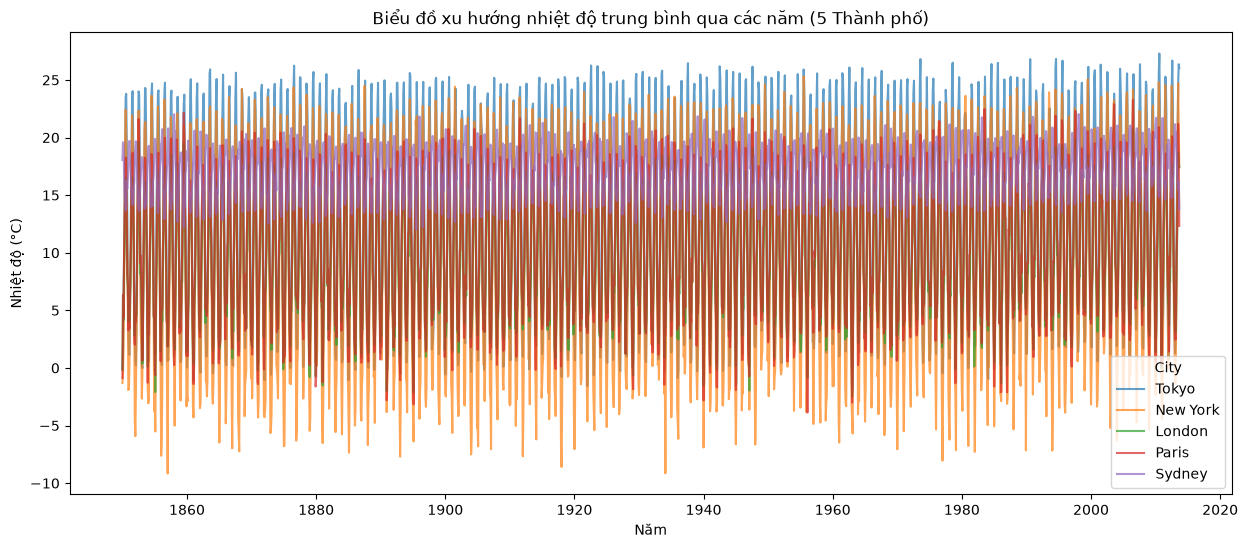

In [21]:
plt.figure(figsize=(15, 6))
# Seaborn tự động nhóm và vẽ 5 đường line cực mượt
sns.lineplot(data=city_df, x=city_df.index, y='AverageTemperature', hue='City', alpha=0.7)
plt.title('Biểu đồ xu hướng nhiệt độ trung bình qua các năm (5 Thành phố)')
plt.xlabel('Năm')
plt.ylabel('Nhiệt độ (°C)')
plt.show()

### 3. Đánh giá tính mùa vụ (Seasonality)


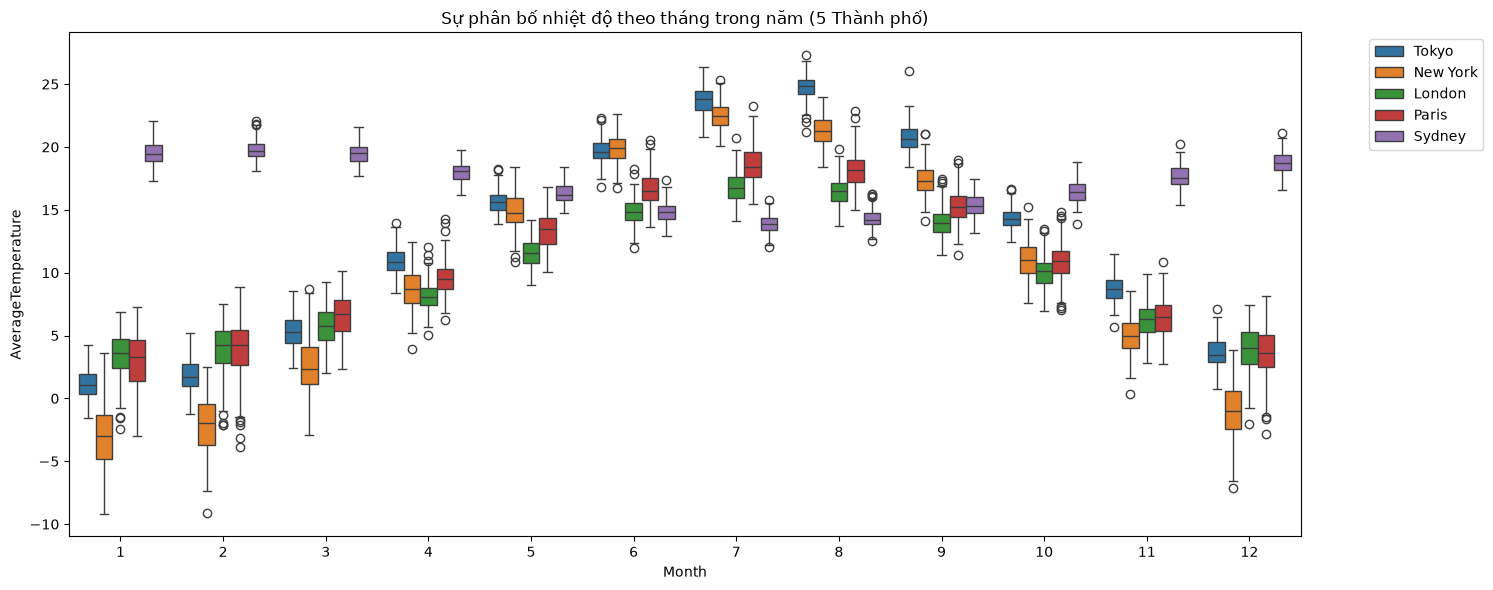

In [22]:
city_df['Month'] = city_df.index.month

plt.figure(figsize=(15, 6))
sns.boxplot(data=city_df, x='Month', y='AverageTemperature', hue='City')
plt.title('Sự phân bố nhiệt độ theo tháng trong năm (5 Thành phố)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Đưa bảng chú thích ra ngoài cho gọn
plt.tight_layout()
plt.show()

## IV. Kết luận EDA
- Nhiệt độ trung bình có dạng phân phối chuẩn hóa và dao động đều đặn.
- Rõ ràng có tính mùa vụ mạnh mẽ: Nhiệt độ đạt đỉnh vào tháng 8 và chạm đáy vào tháng 1-2 hằng năm.
- Có xu hướng tăng nhẹ về lâu dài (do hiện tượng nóng lên toàn cầu).

## V. Liên kết sang Notebook 05
Do tính mùa vụ rất rõ ràng, việc thêm các đặc trưng thời gian (Lag_1, Lag_12, Rolling Mean) sẽ cực kỳ hữu ích để nâng cao độ chính xác cho mô hình Machine Learning ở bước sau.
